In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.base import BaseEstimator, ClassifierMixin

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    selection_rate,
    false_positive_rate,
    false_negative_rate,
    true_positive_rate,
)
from sklearn.metrics import accuracy_score

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet('../data/loans_clean.parquet')

df['dti'] = df['dti'].replace([-1, 999], np.nan).clip(upper=100)
df["credit_history_months"] = df['credit_history_months'].replace(999, np.nan)
df['annual_inc'] = df["annual_inc"].clip(upper=1_000_000)
df['revol_util'] = df['revol_util'].clip(upper=100)

df_val   = df[df["issue_year"] == 2016].copy()
y_val   = df_val['default'].values


print(f"Val loans: {len(df_val):,}")

Val loans: 293,095


In [2]:
df_val_fe = df_val.copy()

def prep_features(df):
    df = df.copy()
    
    redundant = [
        "fico_range_high",
        "funded_amnt",
        "funded_amnt_inv",
        "num_sats",
        "installment",
        "num_rev_tl_bal_gt_0",
    ]

    joint_cols = [c for c in df.columns if c.startswith("sec_app") or c.endswith("_joint")]

    high_cardinality = ["zip_code", "sub_grade"]

    split_cols = ["issue_year"]

    emp_map = {
        "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
        "5 years": 5, "6 years": 6, '7 years': 7, "8 years": 8, "9 years": 9,
        "10+ years": 10
    }
    df["emp_length"] = df["emp_length"].map(emp_map)
    
    cols_to_drop = redundant + joint_cols + high_cardinality + split_cols
    
    df = df.drop(
        columns=[c for c in cols_to_drop if c in df.columns]
    )
    
    return df



df_val_fe = prep_features(df_val_fe)
x_val = df_val_fe.drop(columns=['default'])
x_val['term'] = x_val['term'].str.extract(r'(\d+)').astype(int)

numeric_cols = x_val.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = x_val.select_dtypes(include=['object']).columns.tolist()

x_val[numeric_cols] = x_val[numeric_cols].astype('float64')

champion = joblib.load("../models/champion_lgbm.pkl")

class CalibratedChampionClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, preprocessor,  model, calibrator, threshold):
        self.preprocessor = preprocessor
        self.model = model
        self.calibrator = calibrator
        self.threshold = threshold
        self.classes_ = np.array([0, 1])
    def fit(self, X, y):
        return self
    def predict_proba(self,X):
        X_proc = self.preprocessor.transform(X)
        raw = self.model.predict_proba(X_proc)[:, 1]
        cal = self.calibrator.predict(raw)
        return np.column_stack([1 - cal, cal])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)


champion_clf = CalibratedChampionClassifier(
    preprocessor=champion['preprocessor'],
    model=champion['base_model'],
    calibrator=champion['calibrator'],
    threshold=champion['best_threshold']
)
best_threshold = champion['best_threshold']

y_pred_proba = champion_clf.predict_proba(x_val)[:, 1]
y_pred = (y_pred_proba >= best_threshold).astype(int)

print(f"Threshold: {best_threshold:.4f}")
print(f"Predicted defaults (rejections): {y_pred.sum():,} ({y_pred.mean():.1%})")
print(f"Actual defaults: {y_val.sum():,} ({y_val.mean():.1%})")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold: 0.1592
Predicted defaults (rejections): 183,473 (62.6%)
Actual defaults: 68,242 (23.3%)


In [3]:
sensitive = pd.DataFrame({
    'addr_state': x_val['addr_state'].values,
    'home_ownership': x_val['home_ownership'].values,
}, index= x_val.index)

sensitive['income_tier'] = pd.qcut(
    x_val['annual_inc'],
    q=4,
    labels=['Q1_low', 'Q2', 'Q3', 'Q4_high']
).astype(str)

# Employment length tiers
def emp_tier(yrs):
    if pd.isna(yrs): return 'unknown'
    if yrs <= 1: return 'new_<=1yr'
    if yrs <= 4: return 'short_2-4yr'
    if yrs <= 9: return 'medium_5-9yr'
    return 'long_10yr+'

sensitive['emp_tier'] = x_val['emp_length'].apply(emp_tier)

print("Sensitive attribute distributions:\n")
for col in sensitive.columns:
    if col == 'addr_state':
        print(f"{col}: {sensitive[col].nunique()} unique states")
    else:
        print(f"\n{col}:")
        print(sensitive[col].value_counts().to_string())

Sensitive attribute distributions:

addr_state: 50 unique states

home_ownership:
home_ownership
MORTGAGE    142800
RENT        114602
OWN          35630
ANY             63

income_tier:
income_tier
Q1_low     75765
Q4_high    73011
Q3         72992
Q2         71327

emp_tier:
emp_tier
long_10yr+      99049
short_2-4yr     68529
medium_5-9yr    64379
new_<=1yr       42260
unknown         18878


In [4]:
# metrics for Fairlearn MetricFrame
metrics_dict = {
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate,
    'false_negative_rate': false_negative_rate,
    'true_positive_rate': true_positive_rate,
    'accuracy': accuracy_score,
}

home_mask = sensitive['home_ownership'] != 'ANY'

# MetricFrame for each sensitive attribute
def compute_disparity(y_true, y_pred, sensitive_feature, attr_name, mask=None):
    if mask is not None:
        y_true = y_true[mask]
        y_pred = y_pred[mask]
        sensitive_feature = sensitive_feature[mask]
    
    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_feature,
    )
    
    print(f"\n{'='*80}")
    print(f"{attr_name}")
    print(f"{'='*80}")
    
    print(f"\nPer-group metrics:")
    print(mf.by_group.round(4).to_string())
    
    print(f"\nOverall:")
    print(mf.overall.round(4).to_string())
    
    dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_feature)
    dp_ratio = demographic_parity_ratio(y_true, y_pred, sensitive_features=sensitive_feature)
    eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_feature)
    eo_ratio = equalized_odds_ratio(y_true, y_pred, sensitive_features=sensitive_feature)
    
    print(f"\nDisparity summary:")
    print(f"  Demographic parity difference: {dp_diff:.4f}  (0 = perfect parity)")
    print(f"  Demographic parity ratio:      {dp_ratio:.4f}  (1 = perfect parity, <0.8 = concern)")
    print(f"  Equalized odds difference:     {eo_diff:.4f}  (0 = perfect equality)")
    print(f"  Equalized odds ratio:          {eo_ratio:.4f}  (1 = perfect equality, <0.8 = concern)")
    
    return mf


# Income tier
mf_income = compute_disparity(y_val, y_pred, sensitive['income_tier'], 'INCOME TIER')

# Employment length
mf_emp = compute_disparity(y_val, y_pred, sensitive['emp_tier'], 'EMPLOYMENT LENGTH')

# Home ownership (excluding ANY)
mf_home = compute_disparity(
    y_val, y_pred, sensitive['home_ownership'],
    'HOME OWNERSHIP', mask=home_mask.values
)


INCOME TIER

Per-group metrics:
             selection_rate  false_positive_rate  false_negative_rate  true_positive_rate  accuracy
income_tier                                                                                        
Q1_low               0.7244               0.6640               0.1160              0.8840    0.4865
Q2                   0.6511               0.5825               0.1369              0.8631    0.5266
Q3                   0.6066               0.5390               0.1574              0.8426    0.5460
Q4_high              0.5187               0.4559               0.2102              0.7898    0.5904

Overall:
selection_rate         0.6260
false_positive_rate    0.5580
false_negative_rate    0.1502
true_positive_rate     0.8498
accuracy               0.5369

Disparity summary:
  Demographic parity difference: 0.2057  (0 = perfect parity)
  Demographic parity ratio:      0.7160  (1 = perfect parity, <0.8 = concern)
  Equalized odds difference:     0.2081  (0 = p

In [5]:
# State analysis: 50 groups is too many for a clean MetricFrame summary

state_metrics = []
for state in sensitive['addr_state'].unique():
    mask = sensitive['addr_state'] == state
    n = mask.sum()
    if n < 200:  #skip states with too few samples for reliable stats
        continue
    
    y_t = y_val[mask]
    y_p = y_pred[mask]
    
    if y_t.sum() == 0 or (y_t == 0).sum() == 0:
        continue
    
    state_metrics.append({
        'state': state,
        'n_loans': int(n),
        'selection_rate': y_p.mean(),
        'actual_default_rate': y_t.mean(),
        'fpr': false_positive_rate(y_t, y_p),
        'fnr': false_negative_rate(y_t, y_p),
        'tpr': true_positive_rate(y_t, y_p),
        'accuracy': accuracy_score(y_t, y_p),
    })

state_df = pd.DataFrame(state_metrics).sort_values('selection_rate', ascending=False)

print("Per-state metrics (states with >=200 loans):\n")
print(state_df.round(4).to_string(index=False))

print(f"\n{'='*80}")
print(f"State-level disparity (all states with >=200 loans)")
print(f"{'='*80}")
print(f"  Selection rate: min={state_df['selection_rate'].min():.4f} ({state_df.iloc[-1]['state']}), "
      f"max={state_df['selection_rate'].max():.4f} ({state_df.iloc[0]['state']})")
print(f"  DP difference: {state_df['selection_rate'].max() - state_df['selection_rate'].min():.4f}")
print(f"  DP ratio:      {state_df['selection_rate'].min() / state_df['selection_rate'].max():.4f}")
print(f"  FPR range:     {state_df['fpr'].min():.4f} to {state_df['fpr'].max():.4f}")
print(f"  FNR range:     {state_df['fnr'].min():.4f} to {state_df['fnr'].max():.4f}")

# Rank helper: 1 = highest rejection
def rejection_rank(st):
    row = state_df[state_df['state'] == st]
    if row.empty:
        return None, None, None
    sr  = row['selection_rate'].values[0]
    dr  = row['actual_default_rate'].values[0]
    rk  = int((state_df['selection_rate'] > sr).sum()) + 1
    return sr, dr, rk

# NJ is the state that surfaced in the SHAP low-risk case (addr_state_NJ, +0.11)
print(f"\n  State flagged by SHAP = NJ:")
nj_sr, nj_dr, nj_rk = rejection_rank('NJ')
if nj_sr is not None:
    print(f"    NJ: selection_rate={nj_sr:.4f}, actual_default={nj_dr:.4f}, "
          f"rank {nj_rk} of {len(state_df)} (1 = highest rejection) -> mid-pack, no systemic disparity")
else:
    print(f"    NJ excluded (sample too small)")

# Extremes for context
top, bot = state_df.iloc[0], state_df.iloc[-1]
print(f"    Highest rejection: {top['state']} ({top['selection_rate']:.4f}, default {top['actual_default_rate']:.4f})")
print(f"    Lowest rejection:  {bot['state']} ({bot['selection_rate']:.4f}, default {bot['actual_default_rate']:.4f})")

Per-state metrics (states with >=200 loans):

state  n_loans  selection_rate  actual_default_rate    fpr    fnr    tpr  accuracy
   NE     1455          0.7196               0.2543 0.6599 0.1054 0.8946    0.4811
   MS     1872          0.7169               0.2735 0.6471 0.0977 0.9023    0.5032
   ND      720          0.7125               0.2069 0.6637 0.1007 0.8993    0.4528
   AL     3582          0.7116               0.2758 0.6442 0.1113 0.8887    0.5028
   OK     2786          0.7103               0.2681 0.6449 0.1111 0.8889    0.4982
   AR     2265          0.7082               0.2812 0.6339 0.1020 0.8980    0.5157
   ID      862          0.6995               0.2065 0.6579 0.1404 0.8596    0.4490
   NV     4433          0.6862               0.2481 0.6226 0.1209 0.8791    0.5019
   LA     3271          0.6790               0.2733 0.6029 0.1186 0.8814    0.5295
   NY    23200          0.6709               0.2582 0.6022 0.1315 0.8685    0.5194
   FL    21677          0.6665           

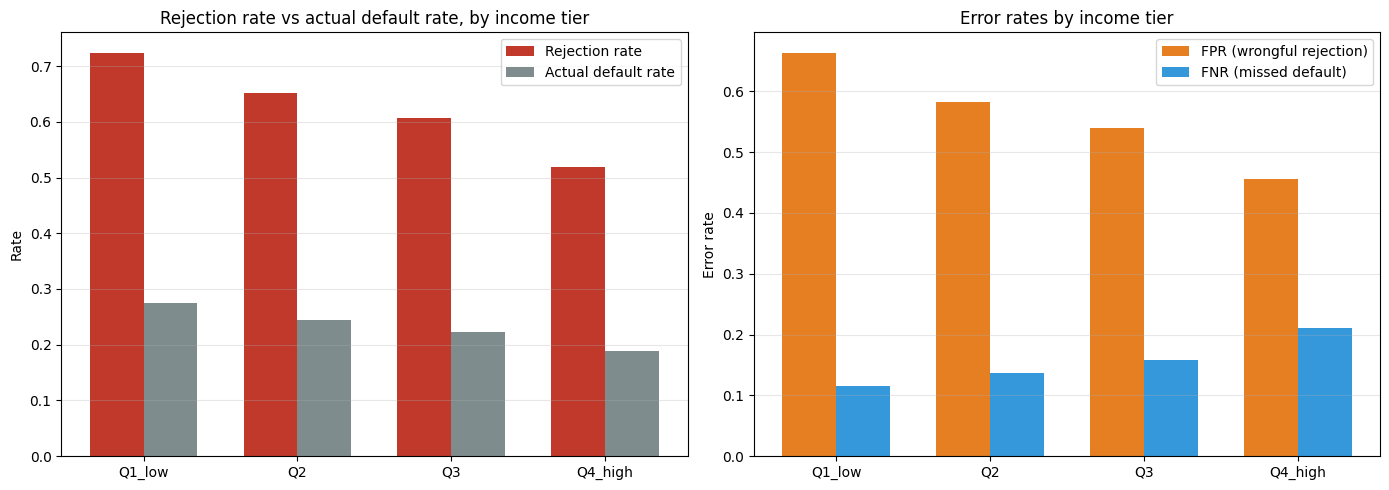

In [6]:
#Income tier disparity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

inc_df = mf_income.by_group.reset_index()
inc_order = ['Q1_low', 'Q2', 'Q3', 'Q4_high']
inc_df = inc_df.set_index('income_tier').loc[inc_order].reset_index()

x = np.arange(len(inc_order))
width = 0.35

axes[0].bar(x - width/2, inc_df['selection_rate'], width, label='Rejection rate', color='#c0392b')
axes[0].bar(x + width/2, [y_val[(sensitive['income_tier'] == t).values].mean() for t in inc_order],
            width, label='Actual default rate', color='#7f8c8d')

axes[0].set_xticks(x)
axes[0].set_xticklabels(inc_order)
axes[0].set_ylabel("Rate")
axes[0].set_title("Rejection rate vs actual default rate, by income tier")

axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width/2, inc_df['false_positive_rate'], width, label='FPR (wrongful rejection)', color='#e67e22')
axes[1].bar(x + width/2, inc_df['false_negative_rate'], width, label='FNR (missed default)', color='#3498db')

axes[1].set_xticks(x)
axes[1].set_xticklabels(inc_order)
axes[1].set_ylabel("Error rate")
axes[1].set_title("Error rates by income tier")
    
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/fairness_income_tier.png", bbox_inches='tight', dpi=150)
plt.show()

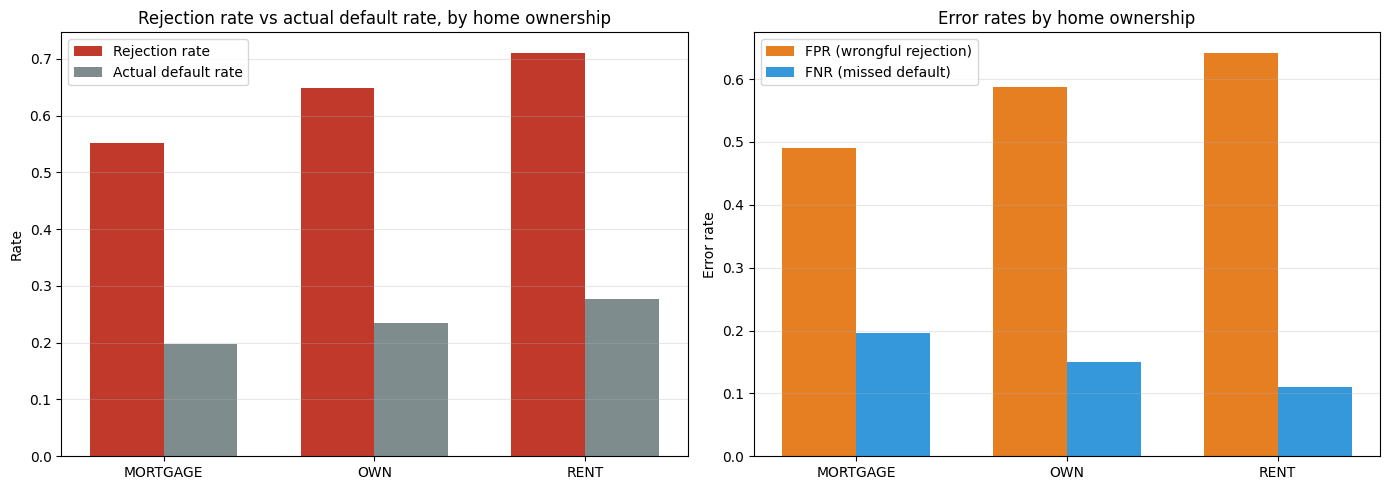

In [7]:
# Home ownership disparity (excluding ANY)
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

home_order = ['MORTGAGE', 'OWN', 'RENT']
home_df = mf_home.by_group.reset_index().set_index('home_ownership').loc[home_order].reset_index()

x = np.arange(len(home_order))

axes[0].bar(x - width/2, home_df['selection_rate'], width, label="Rejection rate", color='#c0392b')
axes[0].bar(x + width/2, [y_val[(sensitive['home_ownership'] == h).values & home_mask.values].mean() for h in home_order],
            width, label='Actual default rate', color='#7f8c8d')

axes[0].set_xticks(x)
axes[0].set_xticklabels(home_order)
axes[0].set_ylabel("Rate")
axes[0].set_title("Rejection rate vs actual default rate, by home ownership")

axes[0].legend()
axes[0].grid(axis= 'y', alpha = 0.3)

axes[1].bar(x - width/2, home_df['false_positive_rate'], width, label="FPR (wrongful rejection)", color='#e67e22')
axes[1].bar(x + width/2, home_df['false_negative_rate'], width, label="FNR (missed default)", color='#3498db')

axes[1].set_xticks(x)
axes[1].set_xticklabels(home_order)
axes[1].set_ylabel("Error rate")
axes[1].set_title("Error rates by home ownership")

axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/fairness_home_ownership.png", bbox_inches='tight', dpi=150)
plt.show()

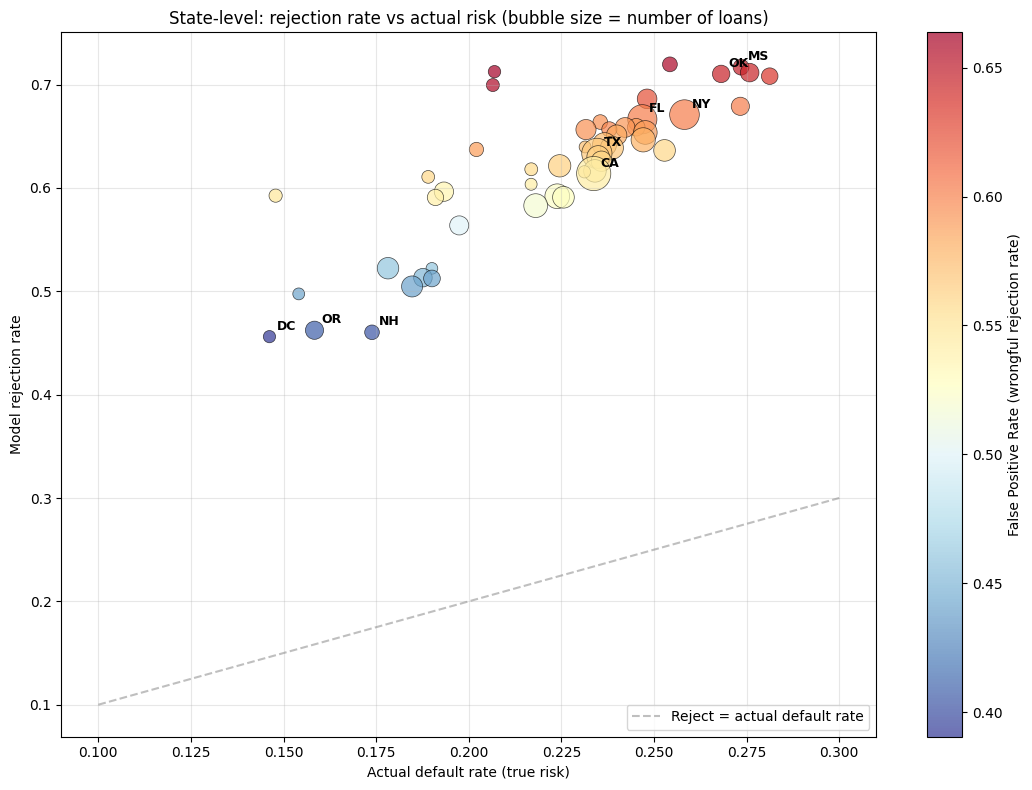

In [8]:
# state-level scatter (actual default rate vs rejection rate)
fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    state_df['actual_default_rate'],
    state_df['selection_rate'],
    s=np.sqrt(state_df['n_loans']) * 3,
    c=state_df['fpr'],
    cmap='RdYlBu_r',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5,
)

lims = [0.10, 0.30]
ax.plot(lims, lims, '--', color='gray', alpha=0.5, label='Reject = actual default rate')

for _, row in state_df.iterrows():
    if row['state'] in ['OK', 'DC', 'OR', 'CA', 'TX', 'NY', 'FL', 'NH', 'MS']:
        ax.annotate(row['state'],
                   (row['actual_default_rate'], row['selection_rate']),
                   fontsize=9, fontweight='bold',
                   xytext=(5, 5), textcoords='offset points')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("False Positive Rate (wrongful rejection rate)")

ax.set_xlabel("Actual default rate (true risk)")
ax.set_ylabel("Model rejection rate")
ax.set_title("State-level: rejection rate vs actual risk (bubble size = number of loans)")

ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/fairness_states_scatter.png", bbox_inches='tight', dpi=150)
plt.show()

In [9]:
# combine income tier and home ownership

sensitive['income_x_home'] = sensitive['income_tier'] + ' | ' + sensitive['home_ownership']

inter_mask = sensitive['home_ownership'] != 'ANY'

mf_inter = MetricFrame(
    metrics=metrics_dict,
    y_true=y_val[inter_mask.values],
    y_pred=y_pred[inter_mask.values],
    sensitive_features=sensitive['income_x_home'][inter_mask.values],
)

inter_df = mf_inter.by_group.copy()
inter_df['n_loans'] = sensitive['income_x_home'][inter_mask.values].value_counts().reindex(inter_df.index).values
inter_df['actual_default'] = [
    y_val[(sensitive['income_x_home'] == g).values & inter_mask.values].mean()
    for g in inter_df.index
]

inter_df = inter_df.sort_values('selection_rate', ascending=False)

print(f"\n{'='*100}")
print(f"INTERSECTIONAL: income tier × home ownership")
print(f"{'='*100}\n")

cols = ['n_loans', 'actual_default', 'selection_rate', 'false_positive_rate', 'false_negative_rate', 'accuracy']
print(inter_df[cols].round(4).to_string())

dp_diff = demographic_parity_difference(
    y_val[inter_mask.values], y_pred[inter_mask.values],
    sensitive_features=sensitive['income_x_home'][inter_mask.values]
)
dp_ratio = demographic_parity_ratio(
    y_val[inter_mask.values], y_pred[inter_mask.values],
    sensitive_features=sensitive['income_x_home'][inter_mask.values]
)
eo_diff = equalized_odds_difference(
    y_val[inter_mask.values], y_pred[inter_mask.values],
    sensitive_features=sensitive['income_x_home'][inter_mask.values]
)
eo_ratio = equalized_odds_ratio(
    y_val[inter_mask.values], y_pred[inter_mask.values],
    sensitive_features=sensitive['income_x_home'][inter_mask.values]
)

print(f"\nIntersectional disparity:")
print(f"  Demographic parity difference: {dp_diff:.4f}")
print(f"  Demographic parity ratio:      {dp_ratio:.4f}")
print(f"  Equalized odds difference:     {eo_diff:.4f}")
print(f"  Equalized odds ratio:          {eo_ratio:.4f}")

# Identify most/least disadvantaged
print(f"\n{'='*100}")
print(f"Most disadvantaged group (highest rejection rate):")
worst = inter_df.iloc[0]
print(f"  {inter_df.index[0]}: rejection {worst['selection_rate']:.1%}, FPR {worst['false_positive_rate']:.1%}, n={int(worst['n_loans']):,}")

print(f"\nLeast disadvantaged group (lowest rejection rate):")
best = inter_df.iloc[-1]
print(f"  {inter_df.index[-1]}: rejection {best['selection_rate']:.1%}, FPR {best['false_positive_rate']:.1%}, n={int(best['n_loans']):,}")

print(f"\nGap (most vs least disadvantaged):")
print(f"  Rejection rate gap: {worst['selection_rate'] - best['selection_rate']:.1%}")
print(f"  FPR gap:            {worst['false_positive_rate'] - best['false_positive_rate']:.1%}")


INTERSECTIONAL: income tier × home ownership

                    n_loans  actual_default  selection_rate  false_positive_rate  false_negative_rate  accuracy
income_x_home                                                                                                  
Q1_low | RENT         40903          0.3011          0.7669               0.7078               0.0959    0.4765
Q1_low | OWN          11387          0.2578          0.7279               0.6744               0.1179    0.4690
Q2 | RENT             29811          0.2797          0.7109               0.6402               0.1070    0.5089
Q3 | RENT             25016          0.2658          0.6823               0.6085               0.1137    0.5230
Q2 | OWN               8494          0.2421          0.6618               0.5968               0.1347    0.5151
Q1_low | MORTGAGE     23461          0.2362          0.6486               0.5892               0.1595    0.5123
Q3 | OWN               7916          0.2284          0.63

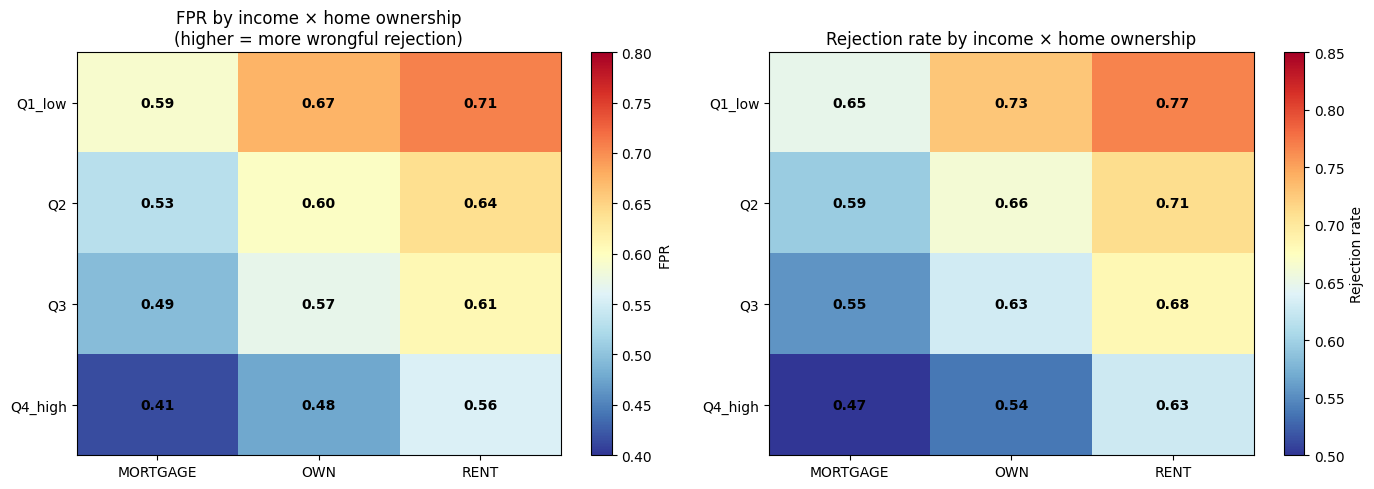

In [10]:
# Heatmap of FPR across income tier × home ownership
inter_pivot = pd.DataFrame(index=['Q1_low', 'Q2', 'Q3', 'Q4_high'], columns=['MORTGAGE', 'OWN', 'RENT'])
for inc in inter_pivot.index:
    for home in inter_pivot.columns:
        group_mask = (sensitive['income_tier'] == inc) & (sensitive['home_ownership'] == home)
        if group_mask.sum() > 100:
            y_t = y_val[group_mask.values]
            y_p = y_pred[group_mask.values]
            if (y_t == 0).sum() > 0:
                inter_pivot.loc[inc, home] = false_positive_rate(y_t, y_p)

inter_pivot = inter_pivot.astype(float)

fig, axes =plt.subplots(1, 2, figsize = (14, 5))

# FPR heatmap
im1 = axes[0].imshow(inter_pivot.values, cmap='RdYlBu_r', aspect='auto', vmin=0.4, vmax=0.8)

axes[0].set_xticks(range(len(inter_pivot.columns)))
axes[0].set_xticklabels(inter_pivot.columns)
axes[0].set_yticks(range(len(inter_pivot.index)))
axes[0].set_yticklabels(inter_pivot.index)
axes[0].set_title("FPR by income × home ownership\n(higher = more wrongful rejection)")

for i in range(len(inter_pivot.index)):
    for j in range(len(inter_pivot.columns)):
        axes[0].text(j, i, f'{inter_pivot.values[i, j]:.2f}',
                    ha='center', va='center', color='black', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='FPR')


sel_pivot = pd.DataFrame(index= ['Q1_low', 'Q2', 'Q3', 'Q4_high'], columns = ['MORTGAGE', 'OWN', 'RENT'])
for inc in sel_pivot.index:
    for home in sel_pivot.columns:
        group_mask = (sensitive['income_tier'] == inc) & (sensitive['home_ownership'] == home)
        if group_mask.sum() > 100:
            sel_pivot.loc[inc, home] = y_pred[group_mask.values].mean()
sel_pivot = sel_pivot.astype(float)

im2 = axes[1].imshow(sel_pivot.values, cmap='RdYlBu_r', aspect='auto', vmin=0.5, vmax=0.85)

axes[1].set_xticks(range(len(sel_pivot.columns)))
axes[1].set_xticklabels(sel_pivot.columns)
axes[1].set_yticks(range(len(sel_pivot.index)))
axes[1].set_yticklabels(sel_pivot.index)
axes[1].set_title("Rejection rate by income × home ownership")
for i in range(len(sel_pivot.index)):
    for j in range(len(sel_pivot.columns)):
        axes[1].text(j, i, f'{sel_pivot.values[i, j]:.2f}',
                    ha='center', va='center', color='black', fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Rejection rate')

plt.tight_layout()
plt.savefig("../reports/figures/fairness_intersectional.png", bbox_inches='tight', dpi=150)
plt.show()